## Pipeline for all hgmm datasets with SoupX

In [ ]:
# please specify which dataset you want to process:
# available options: hgmm1k, hgmm5k, hgmm6k, hgmm10k, hgmm12k, hgmm20k
dataset = "hgmm5k"

# please specifiy path for reading input files
PATH = "hgmm5k"

In [ ]:
import subprocess
import os

dataset_dir = os.path.join(dataset.lower())
os.makedirs(dataset_dir, exist_ok=True)

def download_if_needed(url, target_dir):
    filename = url.split("/")[-1]

    output_path = os.path.join(target_dir, filename)

    if os.path.exists(output_path):
        print(f"File already exists – trying to resume: {filename}")
        subprocess.run(["curl", "-L", "-C", "-", "-o", output_path, url], check=True)
    else:
        print(f"Download file: {filename}")
        subprocess.run(["curl", "-L", "-o", output_path, url], check=True)


if dataset == "hgmm1k":
    urls = [
        "https://cf.10xgenomics.com/samples/cell-exp/4.0.0/SC3_v3_NextGem_DI_Human_Mouse_1K/SC3_v3_NextGem_DI_Human_Mouse_1K_filtered_feature_bc_matrix.h5",
        "https://cf.10xgenomics.com/samples/cell-exp/4.0.0/SC3_v3_NextGem_DI_Human_Mouse_1K/SC3_v3_NextGem_DI_Human_Mouse_1K_raw_feature_bc_matrix.h5"
    ]

elif dataset == "hgmm5k":
    urls = [
        "https://cf.10xgenomics.com/samples/cell-exp/3.0.0/hgmm_5k_v3/hgmm_5k_v3_filtered_feature_bc_matrix.h5",
        "https://cf.10xgenomics.com/samples/cell-exp/3.0.0/hgmm_5k_v3/hgmm_5k_v3_raw_feature_bc_matrix.h5"
    ]

elif dataset == "hgmm6k":
    urls = [
        "https://cf.10xgenomics.com/samples/cell-exp/3.0.2/5k_hgmm_v3_nextgem/5k_hgmm_v3_nextgem_filtered_feature_bc_matrix.h5",
        "https://cf.10xgenomics.com/samples/cell-exp/3.0.2/5k_hgmm_v3_nextgem/5k_hgmm_v3_nextgem_raw_feature_bc_matrix.h5"
    ]

elif dataset == "hgmm10k":
    urls = [
        "https://cf.10xgenomics.com/samples/cell-exp/8.0.0/10k_hgmm_3p_gemx_10k_hgmm_3p_gemx/10k_hgmm_3p_gemx_10k_hgmm_3p_gemx_count_sample_filtered_feature_bc_matrix.h5",
        "https://cf.10xgenomics.com/samples/cell-exp/8.0.0/10k_hgmm_3p_gemx_Multiplex/10k_hgmm_3p_gemx_Multiplex_count_raw_feature_bc_matrix.h5"
    ]

elif dataset == "hgmm12k":
    urls = [
        "https://cf.10xgenomics.com/samples/cell-exp/3.0.2/10k_hgmm_v3_nextgem/10k_hgmm_v3_nextgem_filtered_feature_bc_matrix.h5",
        "https://cf.10xgenomics.com/samples/cell-exp/3.0.2/10k_hgmm_v3_nextgem/10k_hgmm_v3_nextgem_raw_feature_bc_matrix.h5"
    ]

elif dataset == "hgmm20k":
    urls = [
        "https://cf.10xgenomics.com/samples/cell-exp/6.1.0/20k_hgmm_3p_HT_nextgem_Chromium_X/20k_hgmm_3p_HT_nextgem_Chromium_X_filtered_feature_bc_matrix.h5",
        "https://cf.10xgenomics.com/samples/cell-exp/6.1.0/20k_hgmm_3p_HT_nextgem_Chromium_X/20k_hgmm_3p_HT_nextgem_Chromium_X_raw_feature_bc_matrix.h5"
    ]

else:
    raise ValueError("Unknown dataset")


for url in urls:
    download_if_needed(url, dataset_dir)

Download file: SC3_v3_NextGem_DI_Human_Mouse_1K_filtered_feature_bc_matrix.h5


  % Total    % Received % Xferd  Average Speed  Time    Time    Time   Current
                                 Dload  Upload  Total   Spent   Left   Speed
100 13.73M 100 13.73M   0      0 11.10M      0   00:01   00:01         10.84M
  % Total    % Received % Xferd  Average Speed  Time    Time    Time   Current
                                 Dload  Upload  Total   Spent   Left   Speed
  0      0   0      0   0      0      0      0                              0

Download file: SC3_v3_NextGem_DI_Human_Mouse_1K_raw_feature_bc_matrix.h5


100 45.62M 100 45.62M   0      0 11.28M      0   00:04   00:04         11.26M


In [2]:
import scanpy as sc
import seaborn as sns
import numpy as np
import anndata as ad
from scipy.stats import median_abs_deviation
from matplotlib import pyplot as plt
import pandas as pd

/home/luschroe/miniconda3/envs/benchmarking/lib/python3.11/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


In [3]:
# download respective file and specifiy path
adata_raw = sc.read_10x_h5(f"{PATH}/hgmm_5k_v3_raw_feature_bc_matrix.h5")
adata_raw.var_names_make_unique()

/home/luschroe/miniconda3/envs/benchmarking/lib/python3.11/site-packages/anndata/_core/anndata.py:1830: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/luschroe/miniconda3/envs/benchmarking/lib/python3.11/site-packages/anndata/utils.py:111: UserWarning: Suffix used (-[0-9]+) to deduplicate index values may make index values difficult to interpret. There values with a similar suffixes in the index. Consider using a different delimiter by passing `join={delimiter}`Example key collisions generated by the make_index_unique algorithm: ['hg19_SNORD116-1', 'hg19_SNORD116-2', 'hg19_SNORD116-3', 'hg19_SNORD116-5', 'hg19_SNORD116-6']
  warnings.warn(


In [4]:
adata = sc.read_10x_h5(f"{PATH}/hgmm_5k_v3_filtered_feature_bc_matrix.h5")
adata.var_names_make_unique()

/home/luschroe/miniconda3/envs/benchmarking/lib/python3.11/site-packages/anndata/_core/anndata.py:1830: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/luschroe/miniconda3/envs/benchmarking/lib/python3.11/site-packages/anndata/utils.py:111: UserWarning: Suffix used (-[0-9]+) to deduplicate index values may make index values difficult to interpret. There values with a similar suffixes in the index. Consider using a different delimiter by passing `join={delimiter}`Example key collisions generated by the make_index_unique algorithm: ['hg19_SNORD116-1', 'hg19_SNORD116-2', 'hg19_SNORD116-3', 'hg19_SNORD116-5', 'hg19_SNORD116-6']
  warnings.warn(


In [5]:
adata.layers["raw"] = adata.X.copy()

### Quality Control

In [6]:
subset = ["hgmm5k", "hgmm6k", "hgmm12k"]
if dataset in subset:
    mouse_prefix = "mm10_"
elif dataset == "hgmm10k":
    mouse_prefix = "GRCm39_"
else:
    mouse_prefix = "mm10___"

if dataset in subset:
    human_prefix = "hg19_"
else:
    human_prefix = "GRCh38_"

# mitochondrial genes
adata.var["mt"] = adata.var_names.str.startswith((f"{mouse_prefix}mt-", f"{human_prefix}MT-"))
# ribosomal genes
adata.var["ribo"] = adata.var_names.str.startswith((f"{mouse_prefix}Rps", f"{mouse_prefix}Rpl", f"{human_prefix}RPS", f"{human_prefix}RPL"))

In [7]:
sc.pp.calculate_qc_metrics(
    adata, qc_vars=["mt", "ribo"],
    inplace=True,
    percent_top=[20],
    log1p=True
)
adata

AnnData object with n_obs × n_vars = 5366 × 112137
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    layers: 'raw'

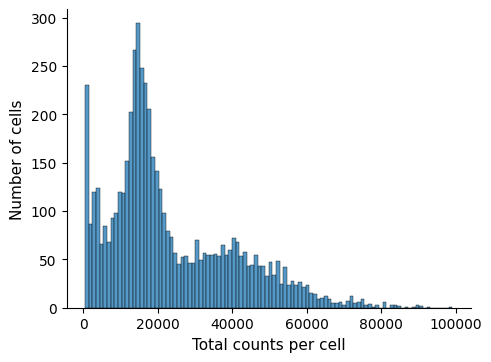

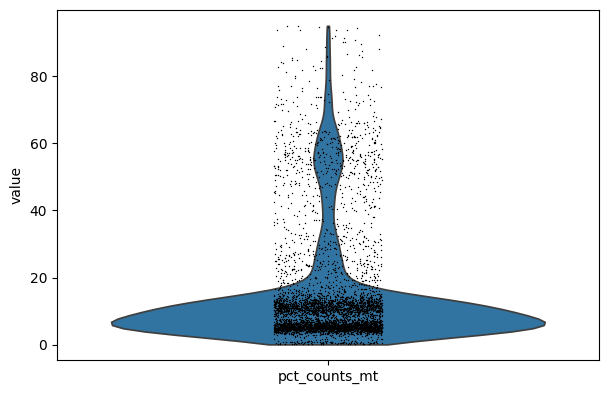

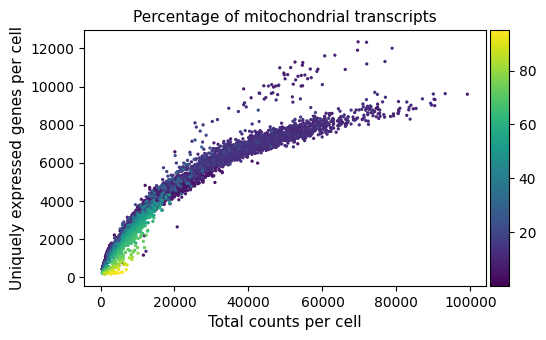

In [8]:
p1 = sns.displot(adata.obs["total_counts"], bins=100, kde=False)
p1.set_axis_labels("Total counts per cell", "Number of cells", fontsize=11)
p1.figure.set_size_inches(5, 3.5)
p2 = sc.pl.violin(adata, "pct_counts_mt")
p3 = sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt", show=False)
p3.set_xlabel("Total counts per cell", fontsize=11)
p3.set_ylabel("Uniquely expressed genes per cell", fontsize=11)
p3.set_title("Percentage of mitochondrial transcripts", fontsize=11)
p3.figure.set_size_inches(6, 3.5)

In [9]:
def is_outlier(adata, metric: str, nmads: int, batch_key: str = None):
    """
    Outlier detection based on MAD (global oder batch-aware).
    """
    values = adata.obs[metric]
    outlier_flags = pd.Series(False, index=adata.obs.index, dtype=bool)

    if batch_key is None:
        # global
        M = values
        med = np.median(M)
        mad = median_abs_deviation(M, scale=1)
        if mad > 0:
            outlier_flags[:] = (M < med - nmads * mad) | (M > med + nmads * mad)
    else:
        # batch-aware
        for batch, idx in adata.obs.groupby(batch_key).groups.items():
            M = values.loc[idx]   
            med = np.median(M)
            mad = median_abs_deviation(M, scale=1)
            if mad == 0:
                continue
            outliers = (M < med - nmads * mad) | (M > med + nmads * mad)
            outlier_flags.loc[idx] = outliers

    return outlier_flags

In [10]:
adata.obs["outlier"] = (
    is_outlier(adata, "log1p_total_counts", 5)
    | is_outlier(adata, "log1p_n_genes_by_counts", 5)
    | is_outlier(adata, "pct_counts_in_top_20_genes", 5)
)
adata.obs.outlier.value_counts()

outlier
False    4302
True     1064
Name: count, dtype: int64

In [11]:
# threshold differs between datasets
high_quality = ["hgmm1k", "hgmm10k"]
if dataset in high_quality:
    threshold = 8
else:
    threshold = 20

adata.obs["mt_outlier"] = adata.obs["pct_counts_mt"] > threshold
adata.obs.mt_outlier.value_counts()

mt_outlier
False    4463
True      903
Name: count, dtype: int64

In [12]:
print(f"Total number of cells: {adata.n_obs}")
adata = adata[(~adata.obs.outlier) & (~adata.obs.mt_outlier)].copy()

print(f"Number of cells after filtering of low quality cells: {adata.n_obs}")

Total number of cells: 5366
Number of cells after filtering of low quality cells: 4241


### Classify human and mouse cells

In [13]:
if dataset != "hgmm10k":
    mouse_genome = "mm10"
else:
    mouse_genome = "GRCm39"

hg19 = ["hgmm5k", "hgmm6k", "hgmm12k"]
if dataset in hg19:
    human_genome = "hg19"
else:
    human_genome = "GRCh38"

adata.obs["human_counts_unc"] = adata[:, adata.var["genome"]==human_genome].layers["raw"].sum(axis=1)
adata.obs["mouse_counts_unc"] = adata[:, adata.var["genome"]==mouse_genome].layers["raw"].sum(axis=1)

In [14]:
adata.obs['human count ratio'] = adata.obs['human_counts_unc']/(adata.obs['mouse_counts_unc'] + adata.obs['human_counts_unc'])
adata.obs['mouse count ratio'] = adata.obs['mouse_counts_unc']/(adata.obs['mouse_counts_unc'] + adata.obs['human_counts_unc'])

In [15]:
import numpy as np

adata.obs['species_raw'] = np.where(
    adata.obs['human count ratio'] > adata.obs['mouse count ratio'],
    'human', 'mouse'
)

adata.obs["majority_ratio"] = np.maximum(
    adata.obs['human count ratio'], adata.obs['mouse count ratio']
)

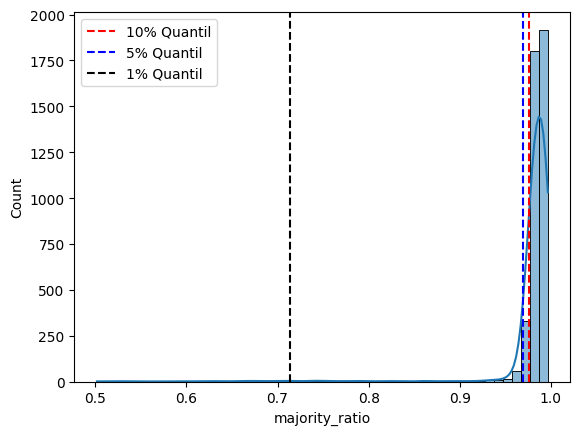

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

vals_human = adata.obs.loc[:, 'majority_ratio']
q90_h = np.percentile(vals_human, 10)
q95_h = np.percentile(vals_human, 5)
q99_h = np.percentile(vals_human, 1)

sns.histplot(vals_human, bins=50, kde=True)
plt.axvline(q90_h, color="red", linestyle="--", label="10% Quantil")
plt.axvline(q95_h, color="blue", linestyle="--", label="5% Quantil")
plt.axvline(q99_h, color="black", linestyle="--", label="1% Quantil")
plt.title("")
plt.legend()
plt.show()

In [17]:
# 5%-Quantil of majority_ratio-distribution
if dataset == "hgmm1k":
    quantile = 1
else:
    quantile = 5

global_thresh = np.percentile(adata.obs["majority_ratio"], quantile)

def refine_species_global(row, global_thresh):
    if row["majority_ratio"] > global_thresh:
        return row["species_raw"]   # stays Human or Mouse
    else:
        return "ambiguous"

adata.obs["species_refined"] = adata.obs.apply(
    refine_species_global, axis=1, args=(global_thresh,)
)


In [18]:
adata.obs['species_refined'].value_counts()

species_refined
mouse        2287
human        1741
ambiguous     213
Name: count, dtype: int64

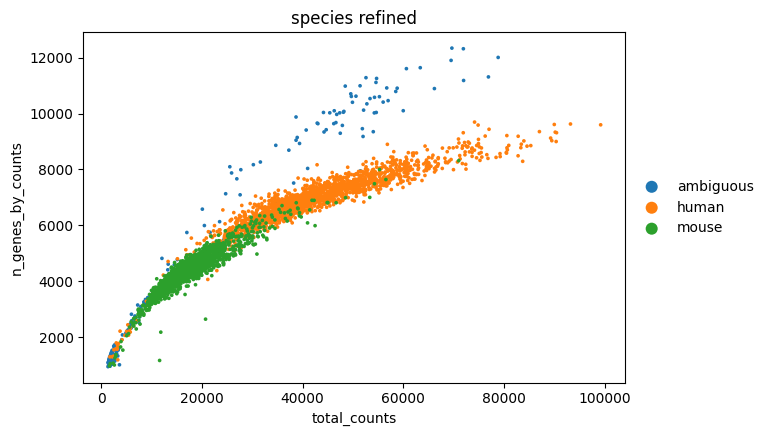

In [19]:
sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="species_refined")

In [20]:
adata.obs["total_counts_unc"] = adata.obs["mouse_counts_unc"] + adata.obs["human_counts_unc"]

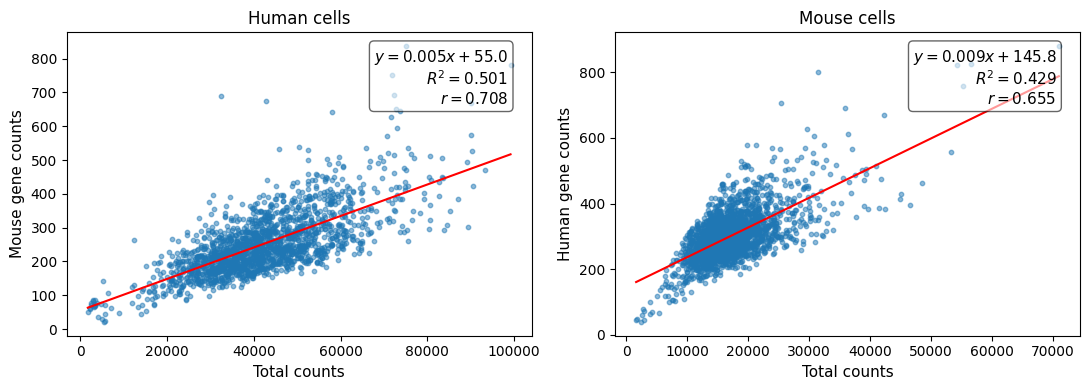

Human cells:
  Steigung (m): 0.0047
  Achsenabschnitt (b): 55.0182
  R² = 0.5013
  Pearson r = 0.7080 (p = 5.04e-265)

Mouse cells:
  Steigung (m): 0.0090
  Achsenabschnitt (b): 145.8407
  R² = 0.4293
  Pearson r = 0.6552 (p = 1.34e-280)


In [21]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score
from scipy.stats import pearsonr

# --- Human cells ---
human_cells = adata[adata.obs["species_refined"] == "human"]
x_h = human_cells.obs["total_counts_unc"]
y_h = human_cells.obs["mouse_counts_unc"]

m_h, b_h = np.polyfit(x_h, y_h, 1)
y_pred_h = m_h * x_h + b_h
r2_h = r2_score(y_h, y_pred_h)
r_h, p_h = pearsonr(x_h, y_h)

# --- Mouse cells ---
mouse_cells = adata[adata.obs["species_refined"] == "mouse"]
x_m = mouse_cells.obs["total_counts_unc"]
y_m = mouse_cells.obs["human_counts_unc"]

m_m, b_m = np.polyfit(x_m, y_m, 1)
y_pred_m = m_m * x_m + b_m
r2_m = r2_score(y_m, y_pred_m)
r_m, p_m = pearsonr(x_m, y_m)

# --- Figure-Layout ---
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# --- Plot 1: Human cells ---
axes[0].scatter(x_h, y_h, alpha=0.5, s=10)
axes[0].plot(np.unique(x_h), np.poly1d((m_h, b_h))(np.unique(x_h)), color='red')
axes[0].set_xlabel("Total counts", fontsize=11)
axes[0].set_ylabel("Mouse gene counts", fontsize=11)
axes[0].set_title("Human cells")
axes[0].text(
    0.95, 0.95,
    f"$y = {m_h:.3f} x + {b_h:.1f}$\n$R^2 = {r2_h:.3f}$\n$r = {r_h:.3f}$",
    transform=axes[0].transAxes,
    fontsize=11,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.6)
)

# --- Plot 2: Mouse cells ---
axes[1].scatter(x_m, y_m, alpha=0.5, s=10)
axes[1].plot(np.unique(x_m), np.poly1d((m_m, b_m))(np.unique(x_m)), color='red')
axes[1].set_xlabel("Total counts", fontsize=11)
axes[1].set_ylabel("Human gene counts", fontsize=11)
axes[1].set_title("Mouse cells")
axes[1].text(
    0.95, 0.95,
    f"$y = {m_m:.3f} x + {b_m:.1f}$\n$R^2 = {r2_m:.3f}$\n$r = {r_m:.3f}$",
    transform=axes[1].transAxes,
    fontsize=11,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.6)
)

plt.tight_layout()
plt.show()

# --- Results in Terminal ---
print("Human cells:")
print(f"  Steigung (m): {m_h:.4f}")
print(f"  Achsenabschnitt (b): {b_h:.4f}")
print(f"  R² = {r2_h:.4f}")
print(f"  Pearson r = {r_h:.4f} (p = {p_h:.2e})\n")

print("Mouse cells:")
print(f"  Steigung (m): {m_m:.4f}")
print(f"  Achsenabschnitt (b): {b_m:.4f}")
print(f"  R² = {r2_m:.4f}")
print(f"  Pearson r = {r_m:.4f} (p = {p_m:.2e})")


### Ambient RNA correction

#### SoupX

In [22]:
from rpy2.robjects import pandas2ri
from rpy2.robjects.conversion import localconverter
from rpy2.robjects import numpy2ri
import rpy2.robjects.packages as rpackages
from rpy2.robjects import r
from rpy2.robjects.packages import importr
import rpy2.rinterface_lib.callbacks as rcb
import logging

rcb.logger.setLevel(logging.ERROR)

%load_ext rpy2.ipython

In [23]:
# load R packages
r('''
library(SoupX)
library(Matrix)
''')


    an issue that caused a segfault when used with rpy2:
    https://github.com/rstudio/reticulate/pull/1188
    Make sure that you use a version of that package that includes
    the fix.
    

In [24]:
adata_pp = adata.copy()
sc.pp.normalize_per_cell(adata_pp)
sc.pp.log1p(adata_pp)

/tmp/ipykernel_65035/1597906230.py:2: FutureWarning: Use sc.pp.normalize_total instead
  sc.pp.normalize_per_cell(adata_pp)
/home/luschroe/miniconda3/envs/benchmarking/lib/python3.11/site-packages/scanpy/preprocessing/_simple.py:590: FutureWarning: Use sc.pp.normalize_total instead
  normalize_per_cell(


In [25]:
sc.pp.pca(adata_pp)
sc.pp.neighbors(adata_pp)
sc.tl.leiden(adata_pp, key_added="soupx_groups")

# Preprocess variables for SoupX
soupx_groups = adata_pp.obs["soupx_groups"]

/tmp/ipykernel_65035/1913318786.py:3: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata_pp, key_added="soupx_groups")


In [26]:
del adata_pp

In [27]:
cells = adata.obs_names
genes = adata.var_names
data = adata.X.T

In [28]:
adata_raw.var_names_make_unique()
data_tod = adata_raw.X.T

In [29]:
del adata_raw

In [30]:
def scipy_csc_to_r_dgc(X, r_name):
    import numpy as np
    import scipy.sparse as sp
    from rpy2.robjects import IntVector, FloatVector, r

    if not sp.isspmatrix_csc(X):
        X = X.tocsc()

    X.sum_duplicates()
    X.sort_indices()

    r.assign("x", FloatVector(np.array(X.data, dtype=np.float64)))
    r.assign("i", IntVector(np.array(X.indices, dtype=np.int32)))
    r.assign("p", IntVector(np.array(X.indptr, dtype=np.int32)))
    r.assign("dims", IntVector(np.array(X.shape, dtype=np.int32)))

    r(f'''
    library(Matrix)
    {r_name} <- new("dgCMatrix", x = x, i = i, p = p, Dim = dims)
    ''')

In [31]:
scipy_csc_to_r_dgc(data, "data")
scipy_csc_to_r_dgc(data_tod, "data_tod")

In [32]:
%%R -i genes -i cells -i soupx_groups -o out 

# specify row and column names of data
rownames(data) = genes
colnames(data) = cells
rownames(data_tod) <- genes

# Generate SoupChannel Object for SoupX 
sc = SoupChannel(data_tod, data, calcSoupProfile = FALSE)

# Add extra meta data to the SoupChannel object
soupProf = data.frame(row.names = rownames(data), est = rowSums(data)/sum(data), counts = rowSums(data))
sc = setSoupProfile(sc, soupProf)
# Set cluster information in SoupChannel
sc = setClusters(sc, soupx_groups)

# Estimate contamination fraction
sc  = autoEstCont(sc, doPlot=FALSE)
# Infer corrected table of counts and rount to integer
out = adjustCounts(sc, roundToInt = TRUE)

549 genes passed tf-idf cut-off and 388 soup quantile filter.  Taking the top 100.
Using 733 independent estimates of rho.
Estimated global rho of 0.03
Expanding counts from 13 clusters to 4241 cells.
In addition: Warning message:
In sparseMatrix(i = out@i[w] + 1, j = out@j[w] + 1, x = out@x[w],  :
  'giveCsparse' is deprecated; setting repr="T" for you


In [33]:
import rpy2.robjects as ro
from rpy2.robjects.packages import importr
import scipy.sparse

# R Packages
Matrix = importr("Matrix")

# 'out' is a R dgCMatrix object
# direct conversion to scipy.sparse.csc_matrix
out_python = scipy.sparse.csc_matrix(
    (list(ro.r('out@x')), list(ro.r('out@i')), list(ro.r('out@p'))), 
    shape=tuple(ro.r('dim(out)'))
)

In [34]:
# save corrected counts in layer and use corrected count matrix
adata.layers["corr"] = out_python.T
adata.X = adata.layers["corr"].copy()

In [ ]:
# use float32 for compatibility with scrublet
adata.X = adata.X.astype(np.float32)
for layer in adata.layers:
    adata.layers[layer] = adata.layers[layer].astype(np.float32)

### Doublet detection

In [ ]:
# doublet detection with scrublet
sc.pp.scrublet(adata)

### Normalization

In [36]:
scales_counts = sc.pp.normalize_total(adata, target_sum=None, inplace=False)
# log1p transform
adata.layers["log1p_norm"] = sc.pp.log1p(scales_counts["X"], copy=True)

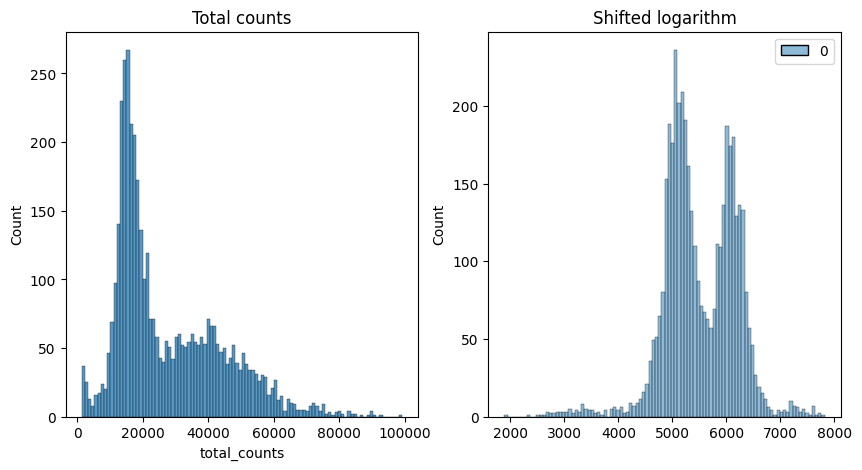

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
p1 = sns.histplot(adata.obs["total_counts"], bins=100, kde=False, ax=axes[0])
axes[0].set_title("Total counts")
p2 = sns.histplot(adata.layers["log1p_norm"].sum(1), bins=100, kde=False, ax=axes[1])
axes[1].set_title("Shifted logarithm")
plt.show()

### Feature selection

In [38]:
# pca was calculated on all genes!
sc.pp.highly_variable_genes(adata, flavor='seurat_v3', n_top_genes=2000)

### Dimensionality reduction

In [39]:
adata.X = adata.layers["log1p_norm"]

In [40]:
# scaling can improve PCA
sc.pp.scale(adata, max_value=10)

/home/luschroe/miniconda3/envs/benchmarking/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


In [41]:
# use all genes not only hvgs
sc.pp.pca(adata, svd_solver="arpack", use_highly_variable=False)

/home/luschroe/miniconda3/envs/benchmarking/lib/python3.11/site-packages/scanpy/preprocessing/_pca/__init__.py:226: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(


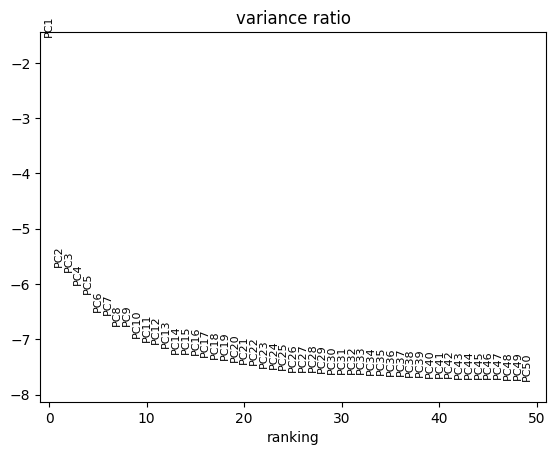

In [42]:
# compute variance ratio across Principal Component
sc.pl.pca_variance_ratio(adata, log=True, n_pcs=50)

In [43]:
# compute tsne
sc.tl.tsne(adata, use_rep="X_pca")

In [44]:
# compute neighbors and umap
sc.pp.neighbors(adata)
sc.tl.umap(adata, random_state=42)

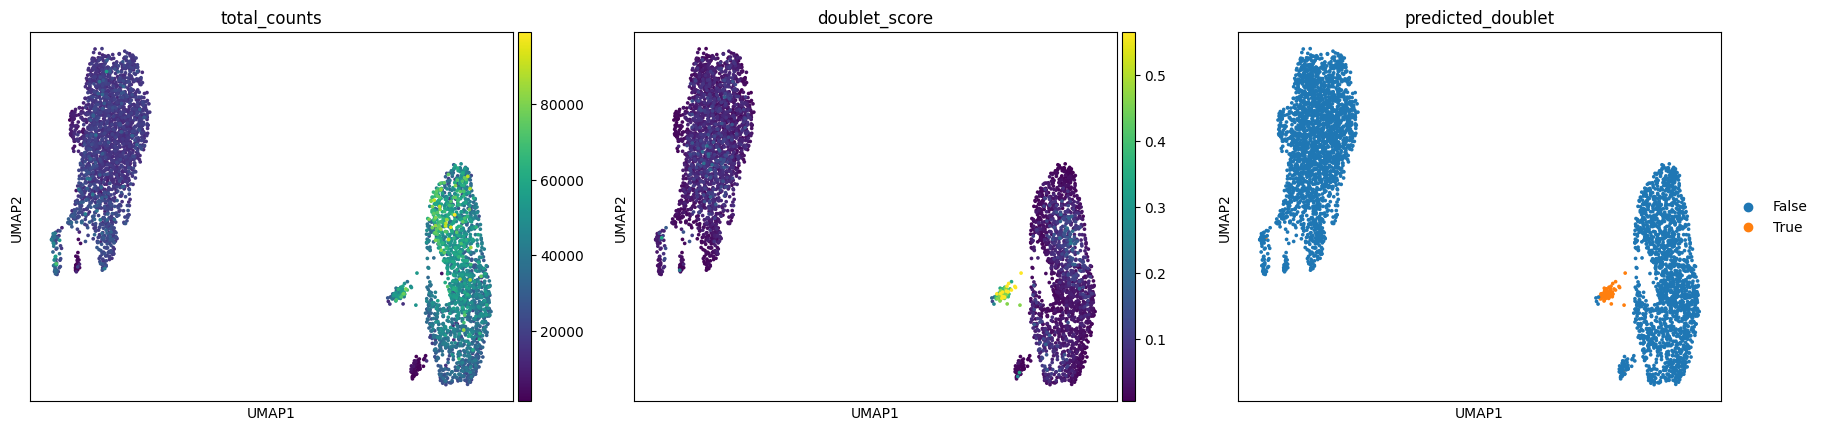

In [45]:
# inspecting quality control metrics
sc.pl.umap(
    adata,
    color=["total_counts", "doublet_score", "predicted_doublet"],
)

### Clustering

In [46]:
sc.tl.leiden(adata, key_added="leiden_res0_25", resolution=0.25)
sc.tl.leiden(adata, key_added="leiden_res0_5", resolution=0.5)
sc.tl.leiden(adata, key_added="leiden_res1", resolution=1.0)

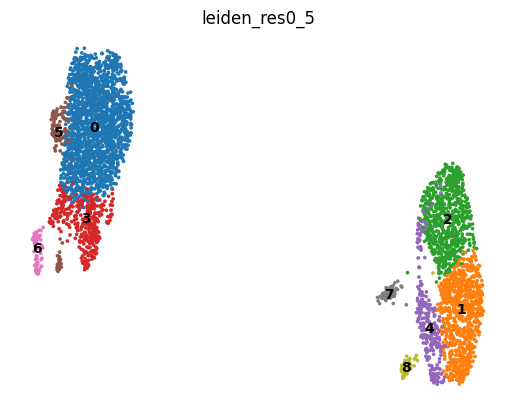

In [47]:
sc.pl.umap(
    adata,
    color= "leiden_res0_5",
    legend_loc="on data",
    frameon=False
)

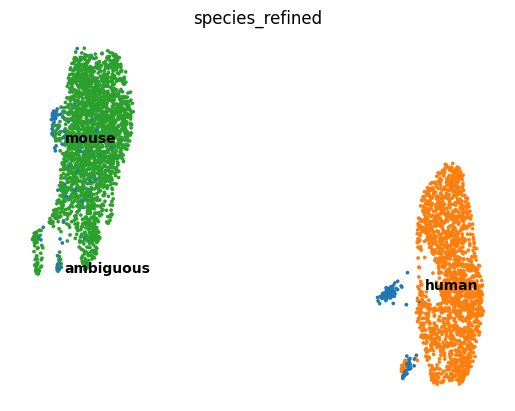

In [48]:
sc.pl.umap(
    adata,
    color= "species_refined",
    legend_loc="on data",
    frameon=False
)

In [49]:
sc.write(f"{PATH}/{dataset}_soupx_processed.h5ad", adata)